# 🧑‍🏫 Aula 7 — LLMs + RAG com LangChain

**UC:** Machine Learning | **Data:** 27/05/2026 | **Duração:** 3 horas

---

## 🎯 Objetivos desta Aula

Na **Aula 6** construímos modelos de **NLP** para classificar sentimentos em reviews usando redes neurais (LSTM/GRU). Agora vamos dar um salto: em vez de **treinar** um modelo do zero, vamos usar **modelos de linguagem pré-treinados (LLMs)** para responder perguntas sobre documentos industriais.

O problema: na fábrica têxtil, operadores precisam consultar **manuais técnicos de centenas de páginas** para resolver problemas nos teares. Vamos construir um **assistente inteligente** que responde perguntas sobre o manual usando a técnica **RAG (Retrieval-Augmented Generation)**.

### O que você vai aprender nesta aula:

1. 🧠 **LLMs** — O que são, arquitetura Transformer simplificada, API vs modelo local
2. 📄 **Document Loaders** — Como carregar PDFs com LangChain
3. ✂️ **Text Splitters** — Dividir documentos grandes em chunks gerenciáveis
4. 📊 **Embeddings** — Transformar texto em vetores numéricos para busca semântica
5. 🗄️ **Vector Store (FAISS)** — Indexar e buscar trechos relevantes do manual
6. 🔄 **Pipeline RAG** — Retrieval → Augmented → Generation
7. 🌡️ **Temperatura** — Controle de criatividade vs fidelidade nas respostas
8. 🛡️ **Guardrails** — System prompt para evitar alucinação

### Recapitulando a trilha:

| Aula | Paradigma | Algoritmos | Tipo de dado |
|---|---|---|---|
| 1 | Supervisionado (classif.) | RandomForest | Tabular |
| 2 | Supervisionado (classif.) | SVM, KNN, XGBoost, LightGBM | Tabular |
| 3 | Supervisionado (regressão) | Ridge, Lasso, SVR, XGBRegressor | Tabular |
| 4 | Não supervisionado | Isolation Forest, LOF, OCSVM, DBSCAN | Tabular |
| 5 | Supervisionado (redes neurais) | MLP (tabular) + CNN (imagem) | Tabular + Imagem |
| 6 | Supervisionado (NLP) | TF-IDF + LR/NB, Embedding + LSTM/GRU | Texto |
| **7** | **LLMs + RAG** | **Embeddings + FAISS + LLM (Generativo)** | **Documento PDF** |

---

📦 **Material:** [The Cotton Textile Worker's Handbook](https://archive.org/details/cottontextilewor00inte) — 367 páginas sobre fiação, tecelagem e cálculos têxteis (1920, domínio público)

> 💡 **Contexto industrial:** Operadores de teares frequentemente precisam consultar manuais técnicos extensos. Um assistente RAG permite buscar informações relevantes em segundos, sem precisar ler centenas de páginas.

## 1️⃣ Configuração do Ambiente e Instalação de Bibliotecas

Nesta aula usamos bibliotecas novas do ecossistema **LangChain** para RAG:

| Biblioteca | Para que serve | Novidade? |
|---|---|---|
| `langchain` | Framework para aplicações com LLMs | ✅ **Novo** |
| `langchain-community` | Conectores comunitários (loaders, vectorstores) | ✅ **Novo** |
| `langchain-huggingface` | Integração com HuggingFace | ✅ **Novo** |
| `pypdf` | Leitura de arquivos PDF | ✅ **Novo** |
| `faiss-cpu` | Vector store para busca por similaridade | ✅ **Novo** |
| `sentence-transformers` | Modelos de embedding de texto | ✅ **Novo** |
| `transformers` | Modelos pré-treinados da HuggingFace | ✅ **Novo** |
| `mlflow` | Tracking de experimentos | — |
| `matplotlib` | Visualizações | — |

In [1]:
# ============================================================
# INSTALAÇÃO DAS DEPENDÊNCIAS
# ============================================================
# LangChain é a grande novidade: framework para construir
# aplicações com LLMs (chatbots, RAG, agentes).
# FAISS é a biblioteca do Facebook para busca vetorial rápida.

%pip install -q langchain langchain-classic langchain-community langchain-huggingface langchain-text-splitters pypdf faiss-cpu sentence-transformers transformers torch mlflow matplotlib numpy

Note: you may need to restart the kernel to use updated packages.


In [2]:
# ============================================================
# IMPORTAÇÃO DAS BIBLIOTECAS
# ============================================================

import os
import warnings
warnings.filterwarnings("ignore")

# --- Reduzir verbosidade ---
os.environ["TOKENIZERS_PARALLELISM"] = "false"

# --- LangChain: Framework principal para RAG ---
from langchain_text_splitters import RecursiveCharacterTextSplitter
from langchain_community.document_loaders import PyPDFLoader
from langchain_community.vectorstores import FAISS
from langchain_classic.chains import RetrievalQA
from langchain_core.prompts import PromptTemplate
from langchain_huggingface import HuggingFaceEmbeddings, HuggingFacePipeline

# --- Transformers: Modelos pré-treinados ---
from transformers import AutoTokenizer, AutoModelForSeq2SeqLM, pipeline

# --- Tracking de experimentos ---
import mlflow

# --- Utilitários ---
import numpy as np
import matplotlib.pyplot as plt
import time
import requests
from pathlib import Path

# --- Configuração visual ---
plt.style.use("seaborn-v0_8-whitegrid")

# --- Reprodutibilidade ---
RANDOM_STATE = 42
np.random.seed(RANDOM_STATE)

print("✅ Todas as bibliotecas foram importadas com sucesso!")
print(f"   🤖 LangChain instalado")
print(f"   🗄️ FAISS disponível para busca vetorial")
print(f"   🧠 Transformers para modelos pré-treinados")

✅ Todas as bibliotecas foram importadas com sucesso!
   🤖 LangChain instalado
   🗄️ FAISS disponível para busca vetorial
   🧠 Transformers para modelos pré-treinados


## 2️⃣ Introdução a LLMs (Large Language Models)

### O que é um LLM?

Um **Large Language Model (LLM)** é uma rede neural gigantesca (bilhões de parâmetros) treinada em enormes volumes de texto da internet. Diferente dos modelos que treinamos nas aulas anteriores:

| Aspecto | Modelos Tradicionais (Aulas 1-6) | LLMs (Aula 7) |
|---|---|---|
| **Treinamento** | Treinamos do zero com nossos dados | Já vem pré-treinado |
| **Dados** | Centenas/milhares de amostras | Trilhões de tokens da internet |
| **Parâmetros** | Milhares a milhões | Bilhões (GPT-4: ~1.8T) |
| **Uso** | Tarefa específica (classificar, prever) | Gerar texto, responder perguntas |
| **Customização** | Feature engineering + hiperparâmetros | Prompt engineering + contexto |

### Arquitetura Transformer (Simplificada)

```
Texto de Entrada
      ↓
[ Tokenização ]  → Quebra o texto em tokens (sub-palavras)
      ↓
[ Embedding ]    → Cada token vira um vetor numérico
      ↓
[ Self-Attention ] → Cada token "olha" para todos os outros
      ↓                   (captura contexto e relações)
[ Feed-Forward ]   → Processamento não-linear
      ↓
[ Repete N vezes ] → Várias camadas empilhadas
      ↓
Texto de Saída (próximo token mais provável)
```

O mecanismo de **Self-Attention** é o que torna Transformers tão poderosos: cada palavra pode "prestar atenção" a qualquer outra palavra na frase, capturando dependências de longo alcance.

### API vs Modelo Local

| Abordagem | Vantagens | Desvantagens |
|---|---|---|
| **API** (OpenAI, Azure) | Modelos poderosos, sem GPU local | Custo por token, dependência de rede |
| **Local** (HuggingFace) | Gratuito, privacidade total | Requer GPU/RAM, modelos menores |

## 3️⃣ O que é RAG (Retrieval-Augmented Generation)?

### O Problema da Alucinação

LLMs são treinados com dados até uma certa data de corte. Se você perguntar sobre um **manual específico da sua fábrica**, o LLM vai **inventar** uma resposta (alucinar). Isso é **perigoso** em ambientes industriais!

### A Solução: RAG

**RAG** combina **busca** (Retrieval) com **geração** (Generation):

```
┌─────────────────────────────────────────────────────────────────────┐
│                    PIPELINE RAG                                │
│                                                                 │
│  1️⃣ INDEXAÇÃO (offline, uma única vez):                          │
│  ┌────────┐   ┌────────┐   ┌──────────┐   ┌───────────┐     │
│  │  PDF   │→→→│ Chunks │→→→│ Embeddings │→→→│ VectorStore │     │
│  └────────┘   └────────┘   └──────────┘   └───────────┘     │
│                                                                 │
│  2️⃣ CONSULTA (online, a cada pergunta):                        │
│  ┌─────────┐   ┌──────────┐   ┌─────────────┐   ┌────────┐    │
│  │ Pergunta│→→→│ Embedding │→→→│ Busca FAISS │→→→│ Top-K  │    │
│  └─────────┘   └──────────┘   └─────────────┘   └────────┘    │
│                                                    │            │
│                                                    ▼            │
│  ┌──────────────────────────────────────────────┐       │
│  │  LLM recebe: System Prompt + Contexto + Pergunta │       │
│  │  LLM gera: Resposta baseada APENAS no contexto   │       │
│  └──────────────────────────────────────────────┘       │
└─────────────────────────────────────────────────────────────────────┘
```

### Por que RAG funciona?

1. **Retrieval (Busca):** Encontra os trechos mais relevantes do manual para a pergunta
2. **Augmented (Aumento):** Injeta esses trechos como contexto no prompt do LLM
3. **Generation (Geração):** O LLM gera a resposta usando APENAS o contexto fornecido

Resultado: respostas **fieis ao documento**, sem alucinação!

## 4️⃣ Download e Carregamento do Manual Técnico (PDF)

Vamos usar o livro **"The Cotton Textile Worker's Handbook"** (1920) disponível gratuitamente no Archive.org. É um manual real de 367 páginas sobre:

- Fiação de fios de algodão
- Tecelagem de tecidos
- Cálculos de produção têxtil
- Operação e manutenção de máquinas

> 📚 Este é exatamente o tipo de documento que operadores de uma fábrica têxtil precisariam consultar!

In [3]:
# ============================================================
# 4.1 — DOWNLOAD DO PDF DO MANUAL TÊXTIL
# ============================================================
# Baixamos o PDF diretamente do Internet Archive.
# Este é um livro de domínio público (publicado em 1920).

PDF_URL = "https://archive.org/download/cottontextilewor00inte/cottontextilewor00inte.pdf"
PDF_PATH = Path("manual_textil.pdf")

if not PDF_PATH.exists():
    print("📥 Baixando o manual têxtil do Internet Archive...")
    print(f"   URL: {PDF_URL}")
    print(f"   Isso pode levar 1-2 minutos (arquivo grande)...")

    response = requests.get(PDF_URL, stream=True)
    response.raise_for_status()

    total_size = int(response.headers.get('content-length', 0))
    downloaded = 0

    with open(PDF_PATH, 'wb') as f:
        for chunk in response.iter_content(chunk_size=8192):
            f.write(chunk)
            downloaded += len(chunk)
            if total_size > 0:
                pct = (downloaded / total_size) * 100
                print(f"\r   Progresso: {pct:.1f}% ({downloaded/1024/1024:.1f} MB)", end="")

    print(f"\n\n✅ Download concluído! Tamanho: {PDF_PATH.stat().st_size / 1024 / 1024:.1f} MB")
else:
    print(f"✅ PDF já existe localmente: {PDF_PATH}")
    print(f"   Tamanho: {PDF_PATH.stat().st_size / 1024 / 1024:.1f} MB")

📥 Baixando o manual têxtil do Internet Archive...
   URL: https://archive.org/download/cottontextilewor00inte/cottontextilewor00inte.pdf
   Isso pode levar 1-2 minutos (arquivo grande)...
   Progresso: 100.0% (15.1 MB)

✅ Download concluído! Tamanho: 15.1 MB


In [4]:
# ============================================================
# 4.2 — CARREGAMENTO DO PDF COM LANGCHAIN
# ============================================================
# PyPDFLoader lê cada página do PDF como um "Document" separado.
# Cada Document tem:
#   - page_content: texto da página
#   - metadata: número da página, fonte, etc.

print("📄 Carregando o PDF com LangChain PyPDFLoader...")
loader = PyPDFLoader(str(PDF_PATH))
pages = loader.load()

print(f"\n✅ PDF carregado com sucesso!")
print(f"   📃 Total de páginas: {len(pages)}")
print(f"   🗒️ Caracteres totais: {sum(len(p.page_content) for p in pages):,}")

# Mostrar exemplo de uma página
print(f"\n👁️ Exemplo — Página 50 (primeiros 500 caracteres):")
print("-" * 60)
if len(pages) > 50:
    print(pages[50].page_content[:500])
    print(f"\n📌 Metadados: {pages[50].metadata}")
else:
    print(pages[10].page_content[:500])
    print(f"\n📌 Metadados: {pages[10].metadata}")

📄 Carregando o PDF com LangChain PyPDFLoader...

✅ PDF carregado com sucesso!
   📃 Total de páginas: 434
   🗒️ Caracteres totais: 519,322

👁️ Exemplo — Página 50 (primeiros 500 caracteres):
------------------------------------------------------------
YARNCALCULATIONS1910skeinsfromeachbale,takingtheskeinsfromdiffer-entpartsofthebale.Fromeachoftheseskeins,threereelingsaremadeand,totheirabsolutelydryweight,11percent,isaddedfornormalmoistureregain.Theaveragedenierofthesereelingsisthedenierofthatbaleofsilkandthevariationintheweightofthereelingsindicatesthevariationinthesizeofthesilkinthatparticularbale,ortheuniformityinsize,orotherwise,ofthesilk.Inadditiontotheforegoingtest,asizingtestin,whichlongreelingsaremadeservestoindicatemoreaccuratelytheya

📌 Metadados: {'producer': 'Recoded by LuraDocument PDF v2.28', 'creator': 'Digitized by the Internet Archive', 'creationdate': '2010-04-28T18:48:38+00:00', 'keywords': 'http://www.archive.org/details/cottontextilewor00inte', 'title': "The cotton t

## 5️⃣ Text Splitting — Dividindo o Documento em Chunks

### Por que dividir?

LLMs têm um **limite de contexto** (janela de tokens). Não podemos enviar 367 páginas inteiras! Precisamos:

1. **Dividir** o documento em pedaços menores (chunks)
2. **Buscar** apenas os chunks relevantes para a pergunta
3. **Enviar** só esses chunks como contexto ao LLM

### Parâmetros do Text Splitter:

| Parâmetro | O que faz | Valor usado |
|---|---|---|
| `chunk_size` | Tamanho máximo de cada chunk (em caracteres) | 1000 |
| `chunk_overlap` | Sobreposição entre chunks vizinhos | 200 |
| `separators` | Onde "cortar" preferencialmente | `[\n\n, \n, . , ]` |

A **sobreposição** garante que informações no limite entre dois chunks não sejam perdidas.

```
Chunk 1: [....... texto ........|overlap|]
Chunk 2:                   [|overlap|....... texto ........]
```

In [5]:
# ============================================================
# 5.1 — CONFIGURAÇÃO DO TEXT SPLITTER
# ============================================================
# RecursiveCharacterTextSplitter tenta dividir respeitando
# a estrutura natural do texto (parágrafos > frases > palavras).

text_splitter = RecursiveCharacterTextSplitter(
    chunk_size=1000,       # Máximo de 1000 caracteres por chunk
    chunk_overlap=200,     # 200 caracteres de sobreposição
    length_function=len,   # Função para medir tamanho
    separators=["\n\n", "\n", ". ", " ", ""]  # Ordem de preferência
)

# Aplicar o splitter nas páginas do PDF
print("✂️ Dividindo o documento em chunks...")
chunks = text_splitter.split_documents(pages)

print(f"\n✅ Documento dividido com sucesso!")
print(f"   📃 Páginas originais: {len(pages)}")
print(f"   🪨 Chunks gerados:    {len(chunks)}")
print(f"   📏 Tamanho médio:     {np.mean([len(c.page_content) for c in chunks]):.0f} caracteres")
print(f"   📏 Tamanho mínimo:    {min(len(c.page_content) for c in chunks)} caracteres")
print(f"   📏 Tamanho máximo:    {max(len(c.page_content) for c in chunks)} caracteres")

✂️ Dividindo o documento em chunks...

✅ Documento dividido com sucesso!
   📃 Páginas originais: 434
   🪨 Chunks gerados:    878
   📏 Tamanho médio:     649 caracteres
   📏 Tamanho mínimo:    1 caracteres
   📏 Tamanho máximo:    1000 caracteres


In [6]:
# ============================================================
# 5.2 — VISUALIZAR EXEMPLOS DE CHUNKS
# ============================================================
# Vamos ver como ficaram alguns chunks para entender a divisão.

print("👁️ Exemplos de chunks gerados:")
print("=" * 60)

for i, chunk in enumerate(chunks[20:23]):
    print(f"\n📌 Chunk #{i + 20} (página {chunk.metadata.get('page', '?')})")
    print(f"   Tamanho: {len(chunk.page_content)} caracteres")
    print(f"   Conteúdo (primeiros 300 chars):")
    print(f"   {chunk.page_content[:300]}...")
    print("-" * 60)

👁️ Exemplos de chunks gerados:

📌 Chunk #20 (página 16)
   Tamanho: 810 caracteres
   Conteúdo (primeiros 300 chars):
   Fillingcorkscrewweaves,321Countsof,61cutting,262-flushAlberttwill,312-flushbrokencrowweave,312-flushcrowtwill,312-flushprunelletwill,312-flushsatinweaves,317-flushweaves,310-forkarrangement,Double,285Kinky,262Knockingoff,261motion,280patterns,Fancy,65-ribweaves,321Ruletofindaveragecountsof,68Ruletof...
------------------------------------------------------------

📌 Chunk #21 (página 17)
   Tamanho: 680 caracteres
   Conteúdo (primeiros 300 chars):
   INDEXFly-framechangegears,183frame,Ruletofindpro-ductionof,185frames,175frames.Dimensionsof,189frames.Productionof,186frames,Ruletofindcon-stantfortwiston,181frames,Speedof,188frames,Standardsizesof,189frames,Twistconstantsfor,188Flying,Shuttles,261Foldedyarnsofdifferentcounts,37yarnsofthesamecounts...
------------------------------------------------------------

📌 Chunk #22 (página 17)
   Tamanho: 718 caracteres
   Cont

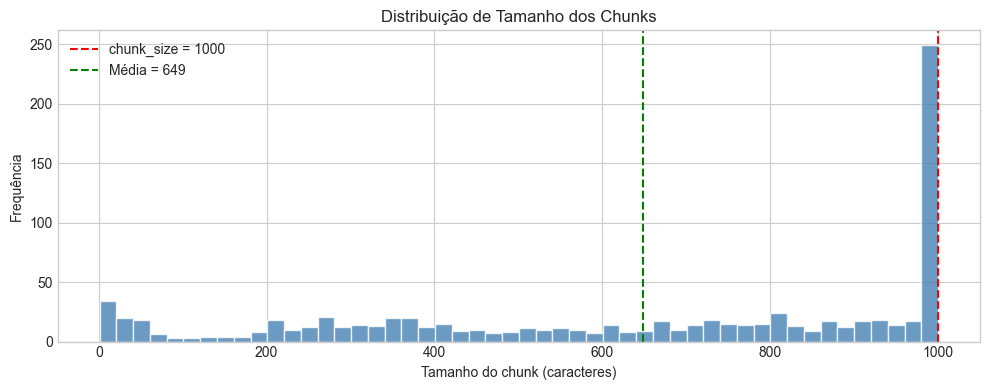


📊 Estatísticas:
   Média: 649 | Mediana: 733
   Min: 1 | Max: 1000


In [7]:
# ============================================================
# 5.3 — DISTRIBUIÇÃO DE TAMANHO DOS CHUNKS
# ============================================================
# Visualizar a distribuição para confirmar que os chunks estão
# dentro do tamanho esperado.

chunk_sizes = [len(c.page_content) for c in chunks]

fig, ax = plt.subplots(1, 1, figsize=(10, 4))
ax.hist(chunk_sizes, bins=50, color="steelblue", edgecolor="white", alpha=0.8)
ax.axvline(x=1000, color="red", linestyle="--", label=f"chunk_size = 1000")
ax.axvline(x=float(np.mean(chunk_sizes)), color="green", linestyle="--",
           label=f"Média = {np.mean(chunk_sizes):.0f}")
ax.set_xlabel("Tamanho do chunk (caracteres)")
ax.set_ylabel("Frequência")
ax.set_title("Distribuição de Tamanho dos Chunks")
ax.legend()
plt.tight_layout()
plt.show()

print(f"\n📊 Estatísticas:")
print(f"   Média: {np.mean(chunk_sizes):.0f} | Mediana: {np.median(chunk_sizes):.0f}")
print(f"   Min: {min(chunk_sizes)} | Max: {max(chunk_sizes)}")

## 6️⃣ Embeddings — Transformando Texto em Vetores

### O que são Embeddings?

**Embeddings** são representações numéricas (vetores) de texto. Textos com significado similar ficam **próximos** no espaço vetorial:

```
"tear parado por defeito"  →  [0.2, 0.8, 0.1, ...] ← próximos!
"máquina com problema"    →  [0.3, 0.7, 0.2, ...] ← próximos!
"preço do algodão"        →  [0.9, 0.1, 0.8, ...] ← distante
```

### Modelo de Embedding Utilizado

Usamos o **`all-MiniLM-L6-v2`** do projeto Sentence-Transformers:
- **Tamanho:** 80MB (leve, roda em CPU)
- **Dimensão:** 384 dimensões por vetor
- **Velocidade:** ~14.000 sentenças/segundo
- **Qualidade:** Excelente para busca semântica em inglês

> 💡 Em produção com Azure OpenAI, usaríamos `text-embedding-ada-002` (1536 dimensões, qualidade superior).

In [8]:
# ============================================================
# 6.1 — CRIAR O MODELO DE EMBEDDINGS
# ============================================================
# HuggingFaceEmbeddings usa sentence-transformers localmente.
# Não precisa de API key — roda 100% no seu computador!

print("🧠 Carregando modelo de embeddings (all-MiniLM-L6-v2)...")
print("   Primeira execução faz download do modelo (~80MB)...")

embeddings_model = HuggingFaceEmbeddings(
    model_name="sentence-transformers/all-MiniLM-L6-v2",
    model_kwargs={"device": "cpu"},  # Roda em CPU (acessível a todos)
    encode_kwargs={"normalize_embeddings": True}  # Normalizar para cosseno
)

print("\n✅ Modelo de embeddings carregado!")

# Testar com um exemplo
test_text = "How to maintain a cotton loom?"
test_embedding = embeddings_model.embed_query(test_text)

print(f"\n🔍 Teste de embedding:")
print(f"   Texto: '{test_text}'")
print(f"   Dimensão do vetor: {len(test_embedding)}")
print(f"   Primeiros 10 valores: {test_embedding[:10]}")

🧠 Carregando modelo de embeddings (all-MiniLM-L6-v2)...
   Primeira execução faz download do modelo (~80MB)...


modules.json:   0%|          | 0.00/349 [00:00<?, ?B/s]

config_sentence_transformers.json:   0%|          | 0.00/116 [00:00<?, ?B/s]

README.md:   0%|          | 0.00/10.5k [00:00<?, ?B/s]

sentence_bert_config.json:   0%|          | 0.00/53.0 [00:00<?, ?B/s]

...

vocab.txt:   0%|          | 0.00/232k [00:00<?, ?B/s]

tokenizer.json:   0%|          | 0.00/466k [00:00<?, ?B/s]

special_tokens_map.json:   0%|          | 0.00/112 [00:00<?, ?B/s]

config.json:   0%|          | 0.00/190 [00:00<?, ?B/s]


✅ Modelo de embeddings carregado!

🔍 Teste de embedding:
   Texto: 'How to maintain a cotton loom?'
   Dimensão do vetor: 384
   Primeiros 10 valores: [-0.04388986900448799, 0.004234890453517437, -0.045072171837091446, -0.003329883562400937, 0.0440666489303112, 0.0023441798985004425, 0.03243117779493332, -0.025137294083833694, -0.0643419548869133, 0.0535820871591568]


In [9]:
# ============================================================
# 6.2 — DEMONSTRAÇÃO: SIMILARIDADE ENTRE TEXTOS
# ============================================================
# Vamos mostrar que embeddings capturam significado semântico.
# Textos similares terão alta similaridade de cosseno.

from numpy import dot
from numpy.linalg import norm

def cosine_similarity(a, b):
    """Calcula similaridade de cosseno entre dois vetores."""
    return dot(a, b) / (norm(a) * norm(b))

# Frases de teste
sentences = [
    "How to fix a broken loom?",           # Manutenção de tear
    "Loom repair and maintenance",          # Manutenção de tear (similar!)
    "Cotton yarn spinning speed",           # Velocidade de fiação
    "The weather is nice today",            # Frase não relacionada
]

# Gerar embeddings para todas
embeddings_list = [embeddings_model.embed_query(s) for s in sentences]

# Calcular matriz de similaridade
print("📊 Matriz de Similaridade de Cosseno:")
print("=" * 60)
print(f"{'':30}", end="")
for i in range(len(sentences)):
    print(f"  [{i}]", end="")
print()

for i, s1 in enumerate(sentences):
    print(f"[{i}] {s1:28}", end="")
    for j, s2 in enumerate(sentences):
        sim = cosine_similarity(embeddings_list[i], embeddings_list[j])
        print(f" {sim:.2f}", end="")
    print()

print("\n💡 Observe:")
print("   - Frases [0] e [1] (ambas sobre manutenção) têm alta similaridade")
print("   - Frase [3] (clima) é muito diferente das demais")

📊 Matriz de Similaridade de Cosseno:
                                [0]  [1]  [2]  [3]
[0] How to fix a broken loom?    1.00 0.82 0.11 0.04
[1] Loom repair and maintenance  0.82 1.00 0.14 0.10
[2] Cotton yarn spinning speed   0.11 0.14 1.00 0.06
[3] The weather is nice today    0.04 0.10 0.06 1.00

💡 Observe:
   - Frases [0] e [1] (ambas sobre manutenção) têm alta similaridade
   - Frase [3] (clima) é muito diferente das demais


## 7️⃣ Vector Store — Indexando os Chunks com FAISS

### O que é FAISS?

**FAISS** (Facebook AI Similarity Search) é uma biblioteca para busca eficiente de vetores similares. Funciona como um "banco de dados vetorial":

1. **Indexação:** Recebe os embeddings de todos os chunks e cria um índice otimizado
2. **Busca:** Dado um vetor de consulta, encontra os K vizinhos mais próximos em milissegundos

| Operação | Complexidade (bruta) | Com FAISS |
|---|---|---|
| Buscar em 1.000 vetores | O(1000) | O(log n) |
| Buscar em 1.000.000 vetores | O(1.000.000) | O(log n) |

> 💡 Em produção, poderíamos usar **Azure AI Search** ou **ChromaDB** como alternativa ao FAISS.

In [10]:
# ============================================================
# 7.1 — CRIAR O VECTOR STORE COM FAISS
# ============================================================
# Aqui acontece a "mágica": cada chunk é transformado em um
# vetor de 384 dimensões e indexado para busca rápida.
# Este passo pode levar 1-3 minutos dependendo do computador.

print("🗄️ Criando Vector Store com FAISS...")
print(f"   Indexando {len(chunks)} chunks...")
print(f"   Cada chunk será convertido em vetor de 384 dimensões...")

start_time = time.time()

vectorstore = FAISS.from_documents(
    documents=chunks,
    embedding=embeddings_model
)

elapsed = time.time() - start_time

print(f"\n✅ Vector Store criado em {elapsed:.1f} segundos!")
print(f"   📊 Total de vetores indexados: {vectorstore.index.ntotal}")
print(f"   📏 Dimensão de cada vetor: {vectorstore.index.d}")

🗄️ Criando Vector Store com FAISS...
   Indexando 878 chunks...
   Cada chunk será convertido em vetor de 384 dimensões...

✅ Vector Store criado em 14.5 segundos!
   📊 Total de vetores indexados: 878
   📏 Dimensão de cada vetor: 384


In [12]:
# ============================================================
# 7.2 — TESTAR A BUSCA SEMÂNTICA (RETRIEVAL)
# ============================================================
# Vamos testar se a busca funciona: fazer uma pergunta e ver
# quais chunks do manual são retornados como mais relevantes.

query = "How to adjust the tension on a loom?"
print(f"🔍 Pergunta: '{query}'")
print("=" * 60)

# Buscar os 4 chunks mais relevantes
results = vectorstore.similarity_search_with_score(query, k=4)

print(f"\n🎯 Top 4 chunks mais relevantes:")
for i, (doc, score) in enumerate(results):
    print(f"\n--- Resultado #{i+1} (score: {score:.4f}) ---")
    print(f"    Página: {doc.metadata.get('page', '?')}")
    print(f"    Trecho: {doc.page_content[:200]}...")

print("\n💡 Scores menores = mais similares (distância euclidiana)")

🔍 Pergunta: 'How to adjust the tension on a loom?'

🎯 Top 4 chunks mais relevantes:

--- Resultado #1 (score: 1.4457) ---
    Página: 356
    Trecho: COTTONDESIGNING...

--- Resultado #2 (score: 1.4692) ---
    Página: 226
    Trecho: COTTON-YARNPREPARATION195Theaccompanyingtablesaregivenasguidesinselectingthesizeoftravelertobeusedforwarpandforfillingyarns.Spindles.—Thespindlesformoneofthemostimportantpartsofaringspinningframe,ando...

--- Resultado #3 (score: 1.4968) ---
    Página: 259
    Trecho: 22^COTTON-YARNPREPARATIONiO(N'-lN>^Oi0i0i©00i-l05O-*05"*OI>'<*'-l05«0-<tii3»l0C^;DM05COTf(«'-H0050000cOCOiOTlHrtl-^COfOeO(N(N(N'--it-H'-"DiMtH^*I-;tHi-irH
co07*ipTt*»ocqico5pa3ooocO'^c<ii-Hi>.cD»oooiT...

--- Resultado #4 (score: 1.5016) ---
    Página: 128
    Trecho: COTTON-YARNPREPARATION97o...

💡 Scores menores = mais similares (distância euclidiana)


In [13]:
# ============================================================
# 7.3 — SALVAR O VECTOR STORE PARA REUTILIZAÇÃO
# ============================================================
# Salvamos o índice FAISS em disco para não precisar
# recalcular os embeddings toda vez que reiniciar.

VECTORSTORE_PATH = "vectorstore_manual_textil"

vectorstore.save_local(VECTORSTORE_PATH)

print(f"✅ Vector Store salvo em: {VECTORSTORE_PATH}/")
print(f"   Arquivos criados:")
for f in Path(VECTORSTORE_PATH).iterdir():
    print(f"   📁 {f.name} ({f.stat().st_size / 1024:.1f} KB)")

print(f"\n💡 Para carregar depois: FAISS.load_local('{VECTORSTORE_PATH}', embeddings_model)")

✅ Vector Store salvo em: vectorstore_manual_textil/
   Arquivos criados:
   📁 index.faiss (1317.0 KB)
   📁 index.pkl (690.8 KB)

💡 Para carregar depois: FAISS.load_local('vectorstore_manual_textil', embeddings_model)


## 8️⃣ Configuração do LLM (Modelo de Linguagem)

### Abordagem desta aula: Modelo Local (HuggingFace)

Para que o notebook funcione **sem necessidade de API keys pagas**, usamos um modelo local da HuggingFace. Em produção, você usaria Azure OpenAI para qualidade muito superior.

| Modelo | Tipo | Tamanho | Qualidade | Custo |
|---|---|---|---|---|
| `google/flan-t5-base` | Local | ~990MB | Média | Gratuito |
| `gpt-4` (Azure OpenAI) | API | N/A | Excelente | ~$0.03/1K tokens |
| `gpt-3.5-turbo` (OpenAI) | API | N/A | Boa | ~$0.002/1K tokens |

> ⚠️ **Nota:** O modelo local `flan-t5-base` é muito menor que GPT-4. As respostas serão mais curtas e menos elaboradas, mas são suficientes para **demonstrar o conceito de RAG**.

### Configuração com Azure OpenAI (Para Produção)

```python
# ==== CONFIGURAÇÃO AZURE OPENAI (descomentar para usar) ====
# from langchain_openai import AzureChatOpenAI
#
# llm = AzureChatOpenAI(
#     azure_deployment="gpt-4",
#     azure_endpoint=os.environ["AZURE_OPENAI_ENDPOINT"],
#     api_key=os.environ["AZURE_OPENAI_API_KEY"],
#     api_version="2024-02-01",
#     temperature=0.0,  # Máxima fidelidade
# )
```

In [14]:
# ============================================================
# 8.1 — CARREGAR O MODELO LOCAL (FLAN-T5)
# ============================================================
# Flan-T5 é um modelo de linguagem treinado pelo Google que
# funciona bem para tarefas de Q&A (pergunta e resposta).
# Primeira execução faz download do modelo (~990MB).
#
# NOTA: Na versão atual do transformers (5.x), o pipeline
# "text2text-generation" foi removido. Usamos model.generate()
# diretamente com um wrapper LangChain customizado.

from langchain_core.language_models.llms import BaseLLM
from langchain_core.outputs import LLMResult, Generation
from typing import Any, List

class FlanT5LLM(BaseLLM):
    """Wrapper LangChain para modelos Seq2Seq (encoder-decoder)."""
    model: Any = None
    tokenizer: Any = None
    max_new_tokens: int = 256
    temperature: float = 0.1
    repetition_penalty: float = 1.2

    @property
    def _llm_type(self) -> str:
        return "flan-t5"

    def _generate(self, prompts: List[str], stop=None, run_manager=None, **kwargs):
        generations = []
        for prompt in prompts:
            inputs = self.tokenizer(prompt, return_tensors="pt", max_length=512, truncation=True)
            outputs = self.model.generate(
                **inputs,
                max_new_tokens=self.max_new_tokens,
                temperature=self.temperature,
                do_sample=True,
                repetition_penalty=self.repetition_penalty
            )
            text = self.tokenizer.decode(outputs[0], skip_special_tokens=True)
            generations.append([Generation(text=text)])
        return LLMResult(generations=generations)

MODEL_NAME = "google/flan-t5-base"

print(f"🧠 Carregando modelo LLM: {MODEL_NAME}")
print(f"   Primeira execução faz download (~990MB)...")

# Carregar tokenizer e modelo
tokenizer = AutoTokenizer.from_pretrained(MODEL_NAME)
model = AutoModelForSeq2SeqLM.from_pretrained(MODEL_NAME)

# Envolver no LangChain usando wrapper customizado
llm = FlanT5LLM(
    model=model,
    tokenizer=tokenizer,
    max_new_tokens=256,
    temperature=0.1,
    repetition_penalty=1.2
)

print(f"\n✅ Modelo carregado com sucesso!")
print(f"   🏠 Tipo: Seq2Seq (encoder-decoder)")
print(f"   📏 Parâmetros: ~250M")
print(f"   🌡️ Temperatura: 0.1 (alta fidelidade)")

# Teste rápido
test_response = llm.invoke("What is cotton weaving?")
print(f"\n🗣️ Teste rápido:")
print(f"   Pergunta: 'What is cotton weaving?'")
print(f"   Resposta: '{test_response}'")

🧠 Carregando modelo LLM: google/flan-t5-base
   Primeira execução faz download (~990MB)...


config.json:   0%|          | 0.00/1.40k [00:00<?, ?B/s]

tokenizer_config.json:   0%|          | 0.00/2.54k [00:00<?, ?B/s]

spiece.model:   0%|          | 0.00/792k [00:00<?, ?B/s]

tokenizer.json:   0%|          | 0.00/2.42M [00:00<?, ?B/s]

...

model.safetensors:   0%|          | 0.00/990M [00:00<?, ?B/s]

Loading weights:   0%|          | 0/282 [00:00<?, ?it/s]

[transformers] The tied weights mapping and config for this model specifies to tie shared.weight to lm_head.weight, but both are present in the checkpoints with different values, so we will NOT tie them. You should update the config with `tie_word_embeddings=False` to silence this warning.


generation_config.json:   0%|          | 0.00/147 [00:00<?, ?B/s]


✅ Modelo carregado com sucesso!
   🏠 Tipo: Seq2Seq (encoder-decoder)
   📏 Parâmetros: ~250M
   🌡️ Temperatura: 0.1 (alta fidelidade)

🗣️ Teste rápido:
   Pergunta: 'What is cotton weaving?'
   Resposta: 'cotton'


## 9️⃣ Pipeline RAG Completo

Agora vamos **juntar tudo** em um pipeline RAG funcional:

1. O usuário faz uma **pergunta**
2. A pergunta é convertida em **embedding**
3. FAISS busca os **top-K chunks** mais relevantes
4. Os chunks são injetados no **prompt** como contexto
5. O LLM gera a **resposta** baseada no contexto

### O Prompt Template

O prompt é a **instrução** que damos ao LLM. Ele define:
- O **papel** do modelo (assistente técnico industrial)
- As **regras** (só responder com base no contexto)
- O **formato** da resposta esperada

In [15]:
# ============================================================
# 9.1 — DEFINIR O PROMPT TEMPLATE (GUARDRAILS)
# ============================================================
# O prompt template é onde definimos os "guardrails" —
# regras que o LLM deve seguir para evitar alucinação.
#
# REGRAS IMPORTANTES:
# 1. Só responder com base no contexto fornecido
# 2. Se não souber, dizer explicitamente
# 3. Citar a página/seção quando possível

PROMPT_TEMPLATE = """You are a technical assistant for a textile factory.
Use ONLY the following context from the Cotton Textile Worker's Handbook to answer the question.
If the answer is not found in the context, say "I cannot find this information in the manual."
Do NOT make up information. Be concise and precise.

Context:
{context}

Question: {question}

Answer:"""

prompt = PromptTemplate(
    template=PROMPT_TEMPLATE,
    input_variables=["context", "question"]
)

print("🛡️ Prompt Template definido com guardrails:")
print("=" * 60)
print(PROMPT_TEMPLATE)
print("=" * 60)
print("\n💡 Guardrails aplicados:")
print("   1. Papel definido: assistente técnico industrial")
print("   2. Só usa contexto fornecido (sem alucinação)")
print("   3. Admite quando não sabe (honestidade)")
print("   4. Respostas concisas e precisas")

🛡️ Prompt Template definido com guardrails:
You are a technical assistant for a textile factory.
Use ONLY the following context from the Cotton Textile Worker's Handbook to answer the question.
If the answer is not found in the context, say "I cannot find this information in the manual."
Do NOT make up information. Be concise and precise.

Context:
{context}

Question: {question}

Answer:

💡 Guardrails aplicados:
   1. Papel definido: assistente técnico industrial
   2. Só usa contexto fornecido (sem alucinação)
   3. Admite quando não sabe (honestidade)
   4. Respostas concisas e precisas


In [16]:
# ============================================================
# 9.2 — CRIAR O RETRIEVER
# ============================================================
# O Retriever é o componente que busca os chunks relevantes.
# Parâmetro k=4 significa: retornar os 4 trechos mais similares.

retriever = vectorstore.as_retriever(
    search_type="similarity",  # Busca por similaridade de cosseno
    search_kwargs={"k": 4}     # Retornar top-4 chunks
)

print("✅ Retriever configurado:")
print(f"   🔍 Tipo de busca: similarity (cosseno)")
print(f"   🎯 Top-K: 4 chunks por consulta")
print(f"   📚 Base: {vectorstore.index.ntotal} chunks indexados")

✅ Retriever configurado:
   🔍 Tipo de busca: similarity (cosseno)
   🎯 Top-K: 4 chunks por consulta
   📚 Base: 878 chunks indexados


In [17]:
# ============================================================
# 9.3 — MONTAR A CHAIN RAG (RetrievalQA)
# ============================================================
# RetrievalQA é a chain do LangChain que conecta:
# Retriever (busca) + LLM (geração) + Prompt (instruções)

from langchain_classic.chains import RetrievalQA

qa_chain = RetrievalQA.from_chain_type(
    llm=llm,
    chain_type="stuff",              # "stuff" = coloca todos os docs no prompt
    retriever=retriever,
    return_source_documents=True,     # Retornar os chunks usados
    chain_type_kwargs={"prompt": prompt}
)

print("✅ Pipeline RAG montado com sucesso!")
print("\n🔄 Fluxo: Pergunta → Retriever → Prompt + Contexto → LLM → Resposta")
print("\n📦 Componentes:")
print(f"   🔍 Retriever: FAISS (top-4 chunks)")
print(f"   🧠 LLM: {MODEL_NAME}")
print(f"   🛡️ Prompt: Com guardrails industriais")

✅ Pipeline RAG montado com sucesso!

🔄 Fluxo: Pergunta → Retriever → Prompt + Contexto → LLM → Resposta

📦 Componentes:
   🔍 Retriever: FAISS (top-4 chunks)
   🧠 LLM: google/flan-t5-base
   🛡️ Prompt: Com guardrails industriais


In [18]:
# ============================================================
# 9.4 — TESTAR O PIPELINE RAG COM PERGUNTAS
# ============================================================
# Vamos fazer perguntas reais sobre o manual têxtil e ver
# como o sistema responde usando RAG.

def ask_question(chain, question):
    """Faz uma pergunta ao pipeline RAG e mostra resultado detalhado."""
    print(f"\n{'='*60}")
    print(f"🗣️ Pergunta: {question}")
    print(f"{'='*60}")

    start = time.time()
    result = chain.invoke({"query": question})
    elapsed = time.time() - start

    print(f"\n🤖 Resposta ({elapsed:.1f}s):")
    print(f"   {result['result']}")

    print(f"\n📄 Fontes utilizadas (chunks recuperados):")
    for i, doc in enumerate(result["source_documents"]):
        page = doc.metadata.get("page", "?")
        print(f"   [{i+1}] Pág. {page}: {doc.page_content[:100]}...")

    return result

# --- Pergunta 1: Sobre operação de tear ---
r1 = ask_question(qa_chain, "What are the main parts of a loom?")

# --- Pergunta 2: Sobre fios ---
r2 = ask_question(qa_chain, "How is yarn count calculated?")

# --- Pergunta 3: Sobre qualidade ---
r3 = ask_question(qa_chain, "What causes defects in woven fabric?")


🗣️ Pergunta: What are the main parts of a loom?

🤖 Resposta (9.8s):
   103 The machinery used in yarn mills for making 200s is as follows: automatic feeder, opener, breaker picker, card, sliver-lap machine, ribbon-lap machine, comber, first dav « ring, sec-ond drawing, third drawing, fourth drawing, slubber, first interradiumate, second intermediate, roving frame, mule. Although the foregoing combinations may be considered as the standards for the class of work to which they refer, it occasionally happens that mills are found using different lay-outs. This may be because the mill is intended to make a low or higher grade of yarn than is customary for the numbers referred to, or because it is a mill that has been changed over from other numbers and, the old machinery has been retained; or there may be many other reasons. The objects of all cotton-yam-preparation machines are: (1) the separation of the matted mass of fiber into loose flakes and the removal of the heavier and more bulky 

In [19]:
# ============================================================
# 9.5 — TESTE DO GUARDRAIL: PERGUNTA FORA DO CONTEXTO
# ============================================================
# O guardrail deve impedir o modelo de "inventar" respostas
# para perguntas que NÃO estão no manual.

print("🛡️ Teste de Guardrail — Pergunta fora do escopo do manual:")
r_guard = ask_question(qa_chain, "What is the stock price of Apple Inc today?")

print("\n" + "─"*60)
print("💡 Observe: o modelo deveria reconhecer que esta informação")
print("   não está no manual e recusar responder (guardrail).")
print("   Com modelos maiores (GPT-4), esse guardrail funciona melhor.")

🛡️ Teste de Guardrail — Pergunta fora do escopo do manual:

🗣️ Pergunta: What is the stock price of Apple Inc today?

🤖 Resposta (3.4s):
   ; 840yd. of the 20 sweighs lb. Consequently, after these yams are folded, there will be 840yd. of a plyyam the weight of which is 5ny + 5V = Alb. The example now resolves itself into the following: What are the counts of a yarn 840yd. of which

📄 Fontes utilizadas (chunks recuperados):
   [1] Pág. 246: ist.Longstockrequireslesstwistthanshortstock,andcombedstocklessthancardedstock.Inmanycg,sestheconsta...
   [2] Pág. 68: ;
840yd.ofthe20sweighs^lb.Consequently,aftertheseyamsarefolded,therewillbe840yd.ofaplyyamtheweightof...
   [3] Pág. 117: 86"DRAFTCALCULATIONSINCREASEINDRAFTOFMETALLICROLLSWeightofGliverLightDraftPerCent.MediumDraftPerCent...
   [4] Pág. 252: =896.748stretches7,000X62Tofindthesizeofthebuilderchangegearrequiredforanycountsofyamwhentheconstant...

────────────────────────────────────────────────────────────
💡 Observe: o modelo deveria 

## 🌡️ Controle de Temperatura

### O que é Temperatura?

A **temperatura** controla a aleatoriedade/criatividade das respostas do LLM:

| Temperatura | Comportamento | Uso ideal |
|---|---|---|
| **0.0** | Determinístico, sempre a mesma resposta | Documentação técnica, fatos |
| **0.3** | Pouca variação, alta fidelidade | RAG industrial, Q&A técnico |
| **0.7** | Variação moderada, criativo | Chatbots, e-mails |
| **1.0** | Máxima criatividade, imprevisível | Escrita criativa, brainstorm |

### Analogia: Temperatura como um Dial

```
Fiel/Preciso  ←────────────────────────────────→  Criativo/Imprevisível
    0.0        0.3        0.5        0.7        1.0
   🏭 Manual   🤖 RAG     💬 Chat    ✍️ E-mail   🎨 Criativo
```

> 🏭 **Para nossa aplicação industrial:** temperatura **baixa** (0.0-0.3) é fundamental! Não queremos criatividade em procedimentos de manutenção!

In [20]:
# ============================================================
# 10.1 — COMPARAÇÃO DE TEMPERATURAS
# ============================================================
# Vamos criar pipelines com diferentes temperaturas e comparar
# as respostas para a mesma pergunta.

temperatures = [0.1, 0.5, 1.0]
question = "What is the purpose of the shuttle in weaving?"

print(f"🌡️ Comparação de Temperaturas")
print(f"   Pergunta: '{question}'")
print("=" * 60)

# Buscar contexto (mesmo para todas as temperaturas)
docs = retriever.invoke(question)
context = "\n\n".join([d.page_content for d in docs])

for temp in temperatures:
    # Formatar prompt com contexto
    full_prompt = PROMPT_TEMPLATE.format(context=context[:1500], question=question)

    # Gerar resposta usando model.generate() com temperatura variável
    inputs = tokenizer(full_prompt, return_tensors="pt", max_length=512, truncation=True)
    outputs = model.generate(
        **inputs,
        max_new_tokens=150,
        temperature=temp,
        do_sample=True,
        repetition_penalty=1.2
    )
    response = tokenizer.decode(outputs[0], skip_special_tokens=True)

    print(f"\n🌡️ Temperatura = {temp}:")
    print(f"   {response}")
    print(f"   {'='*50}")

print("\n💡 Conclusão:")
print("   - Temp 0.1: Resposta mais focada e conservadora")
print("   - Temp 0.5: Alguma variação, mas ainda coerente")
print("   - Temp 1.0: Mais variação, pode fugir do contexto")
print("   🏭 Para aplicação industrial: SEMPRE use temperatura baixa!")

🌡️ Comparação de Temperaturas
   Pergunta: 'What is the purpose of the shuttle in weaving?'

🌡️ Temperatura = 0.1:
   114 COTTON-YARN PREPARATION GEARING The ring of a pincer equipped with the elbow motion illustrated in Fig. 1, is shown in Fig. 4. The beaters shaft is driven from a countershaft, and carries the usual pulleys for driving the fan and feed-rolls. The feed-pulley mi drives a pulley 7W2 on a shaft n extending Fig. 3 across the picker. From this shaft, the cones and the feed-rolls, together with the feed-apron, are driven. As the feed-apron is driven through the cones, its speed will always be

🌡️ Temperatura = 0.5:
   114 COTTON-YARN PREPARATION GEARING The gearing of a picker equipped with the elbow motion illustrated in Fig. 1, is shown in Fig. 4. The beaters shaft is driven from a countershaft, and carries the usual pulleys for driving the fan and feed-rolls. The feed-pulley mi drives a pulley 7W2 on a shaft n extending Fig. 3 across the picker. From this shaft, the con

## 📊 Tracking com MLflow

Mesmo em aplicações RAG, é importante **registrar** as configurações e resultados no MLflow para:

- Comparar diferentes configurações (chunk_size, overlap, k, temperatura)
- Rastrear qual modelo e embeddings foram usados
- Versionar o pipeline RAG como um "modelo" no registry

In [21]:
# ============================================================
# 11.1 — REGISTRAR CONFIGURAÇÃO RAG NO MLFLOW
# ============================================================
# Vamos logar os parâmetros e resultados do pipeline RAG.

# Configurar MLflow
EXPERIMENT_NAME = "aula07_rag_manual_textil"
mlflow.set_tracking_uri("mlruns")
mlflow.set_experiment(EXPERIMENT_NAME)

# Perguntas de teste para avaliação
test_questions = [
    "What are the main parts of a loom?",
    "How is yarn count calculated?",
    "What causes defects in woven fabric?",
    "What is the purpose of the warp?",
    "How to calculate the number of picks per inch?",
]

print("📊 Registrando configuração RAG no MLflow...")

with mlflow.start_run(run_name="rag_flan_t5_base_v1") as run:
    # Logar parâmetros do pipeline
    mlflow.log_param("embedding_model", "sentence-transformers/all-MiniLM-L6-v2")
    mlflow.log_param("llm_model", MODEL_NAME)
    mlflow.log_param("chunk_size", 1000)
    mlflow.log_param("chunk_overlap", 200)
    mlflow.log_param("retriever_k", 4)
    mlflow.log_param("temperature", 0.1)
    mlflow.log_param("max_new_tokens", 256)
    mlflow.log_param("vectorstore_type", "FAISS")
    mlflow.log_param("total_chunks", len(chunks))
    mlflow.log_param("total_pages", len(pages))
    mlflow.log_param("pdf_source", "The Cotton Textile Worker's Handbook (1920)")

    # Executar perguntas de teste e logar respostas
    results_log = []
    for q in test_questions:
        result = qa_chain.invoke({"query": q})
        results_log.append({
            "question": q,
            "answer": result["result"],
            "num_sources": len(result["source_documents"]),
            "source_pages": [d.metadata.get("page", "?") for d in result["source_documents"]]
        })

    # Salvar resultados como artefato
    import json
    results_file = "resultados_rag_test.json"
    with open(results_file, "w", encoding="utf-8") as f:
        json.dump(results_log, f, indent=2, ensure_ascii=False)
    mlflow.log_artifact(results_file)

    # Logar métrica: tempo médio de resposta
    times = []
    for q in test_questions[:3]:  # Só 3 para ser rápido
        start = time.time()
        qa_chain.invoke({"query": q})
        times.append(time.time() - start)

    avg_time = float(np.mean(times))
    mlflow.log_metric("avg_response_time_seconds", avg_time)
    mlflow.log_metric("total_questions_tested", len(test_questions))

    print(f"\n✅ Run registrado no MLflow!")
    print(f"   🆔 Run ID: {run.info.run_id}")
    print(f"   ⏱️ Tempo médio de resposta: {avg_time:.2f}s")
    print(f"   📝 Perguntas testadas: {len(test_questions)}")
    print(f"   📁 Artefato salvo: {results_file}")

2026/05/27 21:45:04 INFO mlflow.tracking.fluent: Experiment with name 'aula07_rag_manual_textil' does not exist. Creating a new experiment.


📊 Registrando configuração RAG no MLflow...

✅ Run registrado no MLflow!
   🆔 Run ID: d09d634ba9e0477e86a84d8c2a380fb0
   ⏱️ Tempo médio de resposta: 3.33s
   📝 Perguntas testadas: 5
   📁 Artefato salvo: resultados_rag_test.json


## 🛡️ Guardrails e Discussão Ética

### Por que Guardrails são Essenciais na Indústria?

Em um ambiente industrial, respostas **erradas** de um LLM podem causar:

| Risco | Exemplo | Consequência |
|---|---|---|
| **Segurança** | Procedimento de manutenção incorreto | Acidente de trabalho |
| **Qualidade** | Parâmetros de produção errados | Lote defeituoso |
| **Financeiro** | Diagnóstico incorreto de falha | Parada desnecessária |

### Estratégias de Guardrails Implementadas:

1. **System Prompt restritivo:** "Use ONLY the context" + "Say I don't know"
2. **Temperatura baixa:** Minimiza criatividade/alucinação
3. **Fonte documentável:** Retorna as páginas de onde veio a resposta
4. **Escopo limitado:** O retriever só busca no manual aprovado

### Discussão Ética

- 🤔 **O LLM deve substituir o técnico?** Não! Ele é uma **ferramenta de apoio**
- 📚 **Qualidade dos dados:** O manual precisa estar correto e atualizado
- 🔒 **Privacidade:** Documentos internos não devem ser enviados a APIs externas sem autorização
- ⚖️ **Responsabilidade:** Quem é responsável se a IA der uma instrução errada?

In [22]:
# ============================================================
# 12.1 — TESTE COMPLETO DO PIPELINE COM VÁRIAS PERGUNTAS
# ============================================================
# Vamos testar o sistema com perguntas variadas para avaliar
# a qualidade das respostas e a eficácia dos guardrails.

perguntas_teste = [
    # Perguntas sobre conteúdo do manual (deve responder)
    "What is the difference between warp and weft?",
    "How many threads are typically used in cotton fabric?",
    "What is the function of a bobbin?",

    # Perguntas fora do escopo (guardrail deve atuar)
    "What is the capital of France?",
    "How to cook pasta?",
]

print("🧪 Teste Completo do Pipeline RAG")
print("=" * 60)

for q in perguntas_teste:
    result = qa_chain.invoke({"query": q})
    in_scope = q not in ["What is the capital of France?", "How to cook pasta?"]
    icon = "🏭" if in_scope else "⚠️"

    print(f"\n{icon} Q: {q}")
    print(f"   A: {result['result'][:200]}")
    if in_scope:
        pages_used = [d.metadata.get('page', '?') for d in result['source_documents']]
        print(f"   📄 Páginas: {pages_used}")
    print()

🧪 Teste Completo do Pipeline RAG

🏭 Q: What is the difference between warp and weft?
   A: WARP PREPARATION 239 WARP PREPARATION 231 whole width of the machine, irrespective of the number of ends being run. Passing from the expansion comb, they come into contact with a drop roll, which take
   📄 Páginas: [278, 270, 266, 268]


🏭 Q: How many threads are typically used in cotton fabric?
   A: I cannot find this information in the manual.
   📄 Páginas: [128, 168, 152, 182]


🏭 Q: What is the function of a bobbin?
   A: f the bobbin, each suc-ceeding layer being slightly shorter than the preceding, which gives to the full bobbin at a per at both ends. When winding they are on a filling-wind bobbin each layer instead 
   📄 Páginas: [222, 318, 222, 380]


⚠️ Q: What is the capital of France?
   A: Paris


⚠️ Q: How to cook pasta?
   A:                                                                                                                                



## 💾 Exportação do Pipeline RAG

Vamos salvar os componentes do pipeline para reutilização:
1. **Vector Store** (já salvo anteriormente)
2. **Configuração** do pipeline em arquivo JSON
3. **Resultados** dos testes

In [23]:
# ============================================================
# 13.1 — EXPORTAR CONFIGURAÇÃO DO PIPELINE
# ============================================================
# Salvamos a configuração completa para que o pipeline possa
# ser reconstruído facilmente.

import json

# Criar pasta de modelos
MODELS_DIR = Path("../modelos/aula07")
MODELS_DIR.mkdir(parents=True, exist_ok=True)

# Configuração do pipeline
pipeline_config = {
    "version": "v1",
    "aula": "07",
    "task": "rag_manual_textil",
    "components": {
        "embedding_model": "sentence-transformers/all-MiniLM-L6-v2",
        "llm_model": MODEL_NAME,
        "vectorstore": "FAISS",
        "vectorstore_path": VECTORSTORE_PATH,
    },
    "parameters": {
        "chunk_size": 1000,
        "chunk_overlap": 200,
        "retriever_k": 4,
        "temperature": 0.1,
        "max_new_tokens": 256,
    },
    "data": {
        "pdf_source": "The Cotton Textile Worker's Handbook (1920)",
        "pdf_url": PDF_URL,
        "total_pages": len(pages),
        "total_chunks": len(chunks),
    },
    "guardrails": {
        "prompt_template": PROMPT_TEMPLATE,
        "strategy": "context-only + explicit uncertainty"
    }
}

config_path = MODELS_DIR / "rag_config_manual_textil_v1.json"
with open(config_path, "w", encoding="utf-8") as f:
    json.dump(pipeline_config, f, indent=2, ensure_ascii=False)

print(f"✅ Configuração exportada: {config_path}")

# Copiar vector store para pasta de modelos
import shutil
vs_dest = MODELS_DIR / "vectorstore_manual_textil_v1"
if vs_dest.exists():
    shutil.rmtree(vs_dest)
shutil.copytree(VECTORSTORE_PATH, vs_dest)

print(f"✅ Vector Store exportado: {vs_dest}")

# Listar arquivos exportados
print(f"\n📁 Arquivos na pasta de modelos:")
for f in sorted(MODELS_DIR.iterdir()):
    if f.is_file():
        print(f"   📄 {f.name} ({f.stat().st_size / 1024:.1f} KB)")
    else:
        print(f"   📂 {f.name}/")
        for sub in f.iterdir():
            print(f"      📄 {sub.name} ({sub.stat().st_size / 1024:.1f} KB)")

✅ Configuração exportada: ..\modelos\aula07\rag_config_manual_textil_v1.json
✅ Vector Store exportado: ..\modelos\aula07\vectorstore_manual_textil_v1

📁 Arquivos na pasta de modelos:
   📄 rag_config_manual_textil_v1.json (1.1 KB)
   📂 vectorstore_manual_textil_v1/
      📄 index.faiss (1317.0 KB)
      📄 index.pkl (690.8 KB)


In [24]:
# ============================================================
# 13.2 — EXPORTAR RESULTADOS DOS TESTES
# ============================================================
# Salvamos os resultados em CSV para referência.

import pandas as pd

# Executar todas as perguntas e coletar resultados
all_questions = test_questions + perguntas_teste
results_data = []

for q in all_questions:
    start = time.time()
    result = qa_chain.invoke({"query": q})
    elapsed = time.time() - start

    results_data.append({
        "question": q,
        "answer": result["result"],
        "response_time_s": round(elapsed, 2),
        "num_sources": len(result["source_documents"]),
        "source_pages": str([d.metadata.get("page", "?") for d in result["source_documents"]])
    })

df_results = pd.DataFrame(results_data)
results_csv_path = "resultados_aula07.csv"
df_results.to_csv(results_csv_path, index=False)

print(f"✅ Resultados exportados: {results_csv_path}")
print(f"\n📊 Resumo:")
print(f"   Total de perguntas: {len(df_results)}")
print(f"   Tempo médio de resposta: {df_results['response_time_s'].mean():.2f}s")
print(f"   Tempo máximo: {df_results['response_time_s'].max():.2f}s")
print(f"\n{df_results[['question', 'answer', 'response_time_s']].to_string()}")

✅ Resultados exportados: resultados_aula07.csv

📊 Resumo:
   Total de perguntas: 10
   Tempo médio de resposta: 4.56s
   Tempo máximo: 10.95s

                                                question                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                 

## 🎯 Resumo da Aula

### O que aprendemos hoje:

| Conceito | O que é | Ferramenta |
|---|---|---|
| **LLMs** | Modelos de linguagem pré-treinados | HuggingFace / Azure OpenAI |
| **Document Loader** | Carregar PDFs para processamento | LangChain PyPDFLoader |
| **Text Splitter** | Dividir documentos em chunks | RecursiveCharacterTextSplitter |
| **Embeddings** | Texto → vetores numéricos | sentence-transformers |
| **Vector Store** | Índice para busca semântica rápida | FAISS |
| **RAG** | Retrieval + Augmented + Generation | LangChain RetrievalQA |
| **Temperatura** | Controle criatividade vs fidelidade | Parâmetro do LLM |
| **Guardrails** | Regras para evitar alucinação | System Prompt + Configuração |

### Pipeline construído:

```
PDF (367 págs) → Chunks (N) → Embeddings → FAISS Index
                                                  ↓
Pergunta → Embedding → Busca Top-4 → Prompt + Contexto → LLM → Resposta
```

### Próxima Aula (Aula 8):
**Aprendizado por Reforço** — Treinar agentes que aprendem por tentativa e erro, aplicado à otimização de operadores de teares.

---

## 🏠 Atividade Complementar (1 hora)

### Objetivo: Otimizar o Pipeline RAG

Você vai **experimentar diferentes configurações** do pipeline RAG e comparar os resultados.

### Tarefa:

1. **Modifique o `chunk_size`** para 500 (menor) e recrie o vector store
2. **Modifique o `retriever_k`** para 6 (buscar mais chunks)
3. **Execute as mesmas 5 perguntas de teste** com a nova configuração
4. **Registre no MLflow** como um novo run (ex: `rag_flan_t5_base_v2`)
5. **Compare** no MLflow: qual configuração teve respostas melhores? Qual foi mais rápida?

### Código Base (modifique os valores marcados com `# ← MODIFICAR`):

In [ ]:
# ============================================================
# 🏠 ATIVIDADE COMPLEMENTAR
# ============================================================
# Modifique os parâmetros abaixo e compare os resultados.

# --- Parâmetros para experimentar ---
NOVO_CHUNK_SIZE = 500       # ← MODIFICAR (original: 1000)
NOVO_CHUNK_OVERLAP = 100    # ← MODIFICAR (original: 200)
NOVO_K = 6                  # ← MODIFICAR (original: 4)



✂️ Novos chunks: 1586 (antes: 878)

🗄️ Criando novo Vector Store...
✅ Novo index: 1586 vetores

🗣️ What are the main parts of a loom?
   103 The machinery used in yarn mills for making 200s is as follows: automatic feeder, opener, breaker picker, card, sliver-lap machine, ribbon-lap mac

🗣️ How is yarn count calculated?
   YARNCALCULATIONSpressed in some other system. For instance, multiplying the counts of a wool yarn by.667 (), or dividing the counts by 1.5i.f), gives 

🗣️ What causes defects in woven fabric?
   Every Saturday, or at such other times as the machines are to be stopped for a considerable period of time, the pressure should be taken off the rolls

🗣️ What is the purpose of the warp?
   .—To find the gear required to give a desired length of traverse when the gear beingn in and the length of traverse it gives are known: PRODUCTION OF 

🗣️ How to calculate the number of picks per inch?
   6 rolls. Weighting of single-boss, 149 Metric system of yarn numbering, 25 system, R

### Perguntas para refletir:

1. Chunks menores (500) trouxeram respostas mais precisas ou mais fragmentadas?
2. Buscar mais chunks (k=6) melhorou ou adicionou ruído às respostas?
3. O tempo de resposta aumentou significativamente?
4. Como você escolheria os parâmetros ideais para produção?

---

**Parabéns!** Você construiu um assistente RAG funcional para documentos industriais! 🎉

Na próxima aula, vamos explorar **Aprendizado por Reforço** — onde agentes aprendem por tentativa e erro, aplicado à otimização de operações na fábrica têxtil.